# Demonstrate CT Images - Corrupted Images vs. GT

Here we visualize CT images with different impairments:

*   **Metal Artifacts Corruption**
*   **Low Dose Images**

Every impairment type describes CT images from a different data set. The deep nn models objective is, when given an impaired CT image (the input), to produce a CT image that has a better quality than the impaired image (measured by metrics such as PSNR, SSIM), when they are compared with the ground truth (the label).

**Note**: the notbook assumes the running is in Google Colab, and that the example images were uploaded to local Files.

In [1]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.0 MB/s eta 0:00:00


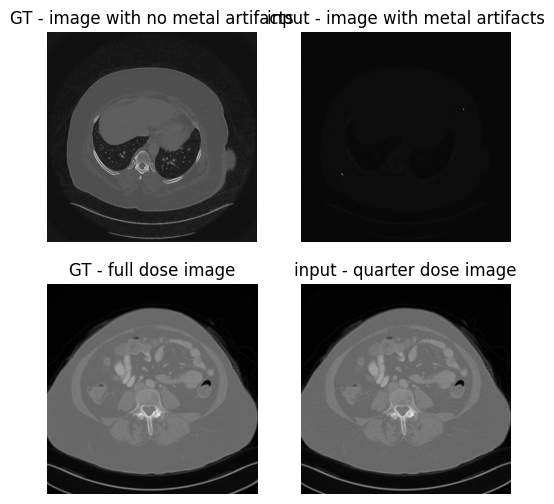

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom

file_path1 = r"/content/training_body_nometal_img12100_512x512x1.raw"
file_path2 = r"/content/training_body_metalart_img12100_512x512x1.raw"
file_path3 = r"/content/L310_FD_3_1.CT.0002.0100.2015.12.22.18.06.56.417912.358120470.IMA"
file_path4 = r"/content/L310_QD_3_1.CT.0004.0100.2015.12.22.18.08.13.181588.358272899.IMA"

raw_data1 = np.fromfile(file_path1, dtype=np.float32)
raw_data2 = np.fromfile(file_path2, dtype=np.float32)

image_matrix1 = raw_data1.reshape((512, 512))
image_matrix2 = raw_data2.reshape((512, 512))

dicom_data1 = pydicom.dcmread(file_path3)
dicom_data2 = pydicom.dcmread(file_path4)

image_array1 = dicom_data1.pixel_array
image_array2 = dicom_data2.pixel_array

plt.figure(figsize=(6, 6))
plt.subplot(2, 2, 1)
plt.imshow(image_matrix1, cmap='gray')
plt.title("GT - image with no metal artifacts")
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(image_matrix2, cmap='gray')
plt.title("input - image with metal artifacts")
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(image_array1, cmap='gray')
plt.title("GT - full dose image")
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(image_array2, cmap='gray')
plt.title("input - quarter dose image")
plt.axis('off')
plt.show()
